In [233]:
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture

import numpy as np


In [247]:
# Example usage
tickers = ['DX-Y.NYB', 'USO', '^VIX', '^TNX', 'IEF','HYG', 'SPY']
start_date = '2009-01-01'

data =yf.download(tickers, start=start_date, end=datetime.now().strftime('%Y-%m-%d'))[['Close']]
data.columns = data.columns.get_level_values(1)
data = data.ffill()
data = data[['DX-Y.NYB', 'USO', '^VIX' , 'SPY','^TNX']]
#data[['DX-Y.NYB_chg', 'USO_chg' , 'SPY_chg','credit_spr_chg' ,'^TNX_chg']] = data[['DX-Y.NYB', 'USO', 'SPY','credit_spr' ,'^TNX']].diff().fillna(0)
data['USO'] = data['USO'].pct_change(10).fillna(0)
data['SPY']= data['SPY'].pct_change(10).fillna(0)  
data['DXY'] = data['DX-Y.NYB'].diff(10)#.fillna(0)
#data['credit_spr'] = data['credit_spr'].diff(20).fillna(0)
data['VIX'] = data['^VIX']
data = data[['DXY', 'USO', 'VIX', 'SPY', '^TNX']]
data = data.iloc[250:]
data

[*********************100%***********************]  7 of 7 completed


Ticker,DXY,USO,VIX,SPY,^TNX
Date,,,,,
2009-12-30,0.950005,0.089340,19.959999,0.015948,3.784
2009-12-31,0.860001,0.069134,21.680000,0.004663,3.843
2010-01-04,-0.160004,0.107536,20.040001,0.034127,3.841
2010-01-05,-0.199997,0.102291,19.350000,0.031032,3.755
2010-01-06,-0.550003,0.133020,19.160000,0.021378,3.808
...,...,...,...,...,...
2025-08-11,-0.140007,-0.043670,16.250000,-0.001601,4.273
2025-08-12,-0.810005,-0.085840,14.730000,0.011696,4.293
2025-08-13,-2.100006,-0.105874,14.490000,0.016439,4.238


In [248]:
sector_etfs = [
    'XLK',   # Technology
    'XLV',   # Healthcare
    'XLF',   # Financials
    'XLY',   # Consumer Discretionary
    'XLP',   # Consumer Staples
    'XLE',   # Energy
    'XLI',   # Industrials
    'XLB',   # Materials
    'XLU',   # Utilities
    'XLRE',  # Real Estate
    'XLC'    # Communication Services
]
sectors = yf.download(sector_etfs, start=start_date, end=datetime.now().strftime('%Y-%m-%d'))[['Close']]
sectors.columns = sectors.columns.get_level_values(1)
#sectors.dropna(inplace = True)
sectors = sectors.diff()


def get_xsec_corr(df, window=60):
    """Calculate rolling average correlation"""
    rolling_corrs = []
    
    for i in range(window-1, len(df)):
        window_data = df.iloc[i-window+1:i+1]
        corr_matrix = window_data.corr()
        
        # Get upper triangle (excluding diagonal)
        mask = np.triu(np.ones_like(corr_matrix), k=1).astype(bool)
        avg_corr = corr_matrix.where(mask).stack().mean()
        rolling_corrs.append(avg_corr)
    
    # Create result series with proper index
    result_index = df.index[window-1:]
    return pd.Series(rolling_corrs, index=result_index)

# Use it
xsec_corr = get_xsec_corr(sectors, window=20)
#sectors = sectors.rolling(20*3,min_periods=10).apply(get_x_sectional_correlation)  # 3 months rolling mean

[*********************100%***********************]  11 of 11 completed


In [249]:
data = pd.concat([data, xsec_corr], axis=1)
data.rename(columns={0: 'Avg_Correlation'}, inplace=True)
data

,DXY,USO,VIX,SPY,^TNX,Avg_Correlation
Date,,,,,,
2009-01-30,NaN,NaN,NaN,NaN,NaN,0.689417
2009-02-02,NaN,NaN,NaN,NaN,NaN,0.680540
2009-02-03,NaN,NaN,NaN,NaN,NaN,0.690064
2009-02-04,NaN,NaN,NaN,NaN,NaN,0.713347
2009-02-05,NaN,NaN,NaN,NaN,NaN,0.715359
...,...,...,...,...,...,...
2025-08-11,-0.140007,-0.043670,16.25,-0.001601,4.273,0.323998
2025-08-12,-0.810005,-0.085840,14.73,0.011696,4.293,0.302972
2025-08-13,-2.100006,-0.105874,14.49,0.016439,4.238,0.313543


In [250]:
data = data.dropna()

In [251]:


def find_optimal_clusters(data, max_clusters=10):
    """
    Find optimal number of clusters using silhouette score
    
    Parameters:
    data: DataFrame or array-like, the dataset to cluster
    max_clusters: int, maximum number of clusters to test (default 10)
    
    Returns:
    int: optimal number of clusters
    """
    # Standardize the data
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)
    
    silhouette_scores = []
    
    for k in range(2, max_clusters + 1):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(data_scaled)
        score = silhouette_score(data_scaled, labels)
        silhouette_scores.append(score)
    
    optimal_k = np.argmax(silhouette_scores) + 2  # +2 because range starts at 2
    return optimal_k

def get_pcs(data):
    """
    Run PCA and return components covering at least 95% of variance
    
    Parameters:
    data: DataFrame or array-like, the dataset for PCA
    
    Returns:
    array: transformed data with components covering >=95% variance
    """
    # Standardize the data
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)
    
    pca = PCA()
    pca.fit(data_scaled)
    
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
    n_components = np.argmax(cumulative_variance >= 0.95) + 1
    
    pca_final = PCA(n_components=n_components)
    transformed_data = pca_final.fit_transform(data_scaled)
    
    return transformed_data

def get_gmm_clusters(data, n_clusters):
    """
    Perform Gaussian Mixture Model clustering
    
    Parameters:
    data: DataFrame or array-like, the dataset to cluster
    n_clusters: int, number of clusters
    
    Returns:
    array: cluster labels for each data point
    """
    # Standardize the data
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)
    
    # Fit Gaussian Mixture Model
    gmm = GaussianMixture(n_components=n_clusters, random_state=42)
    labels = gmm.fit_predict(data_scaled)
    
    return labels

In [252]:
pcs = get_pcs(data)
pcs = pd.DataFrame(pcs, index=data.index, columns=[f'PC{i+1}' for i in range(pcs.shape[1])])
pcs

,PC1,PC2,PC3,PC4,PC5,PC6
Date,,,,,,
2009-12-30,-0.600756,0.312275,0.782618,1.557832,-0.267113,0.474496
2009-12-31,-0.071304,0.332945,0.988782,1.409086,-0.315244,0.377646
2010-01-04,-1.027957,-0.603866,1.262125,1.383215,-0.100039,0.449774
2010-01-05,-0.980066,-0.588031,1.204432,1.291860,-0.103845,0.302494
2010-01-06,-1.120351,-0.686859,1.357805,1.347269,-0.643578,0.145593
...,...,...,...,...,...,...
2025-08-11,-0.636326,1.610987,1.158364,-0.623963,-0.086894,0.541254
2025-08-12,-0.897859,1.489556,1.298265,-1.346657,0.408378,0.607394
2025-08-13,-1.073738,0.958077,1.657134,-2.149323,0.432633,0.534932


In [253]:
spy = yf.download('SPY', start=start_date, end=datetime.now().strftime('%Y-%m-%d'))['Close']

[*********************100%***********************]  1 of 1 completed


In [259]:
regimes = get_gmm_clusters(pcs, n_clusters = 4)
regimes = pd.DataFrame(regimes, index=data.index, columns=['Regime'])
regimes = pd.concat([regimes, spy], axis=1).dropna()
#regimes['SPY'] = (1 + regimes['SPY']).cumprod() - 1
regimes


,Regime,SPY
Date,,
2009-12-30,3.0,84.904419
2009-12-31,3.0,84.089508
2010-01-04,3.0,85.515640
2010-01-05,3.0,85.741997
2010-01-06,3.0,85.802353
...,...,...
2025-08-11,3.0,635.919983
2025-08-12,3.0,642.690002
2025-08-13,3.0,644.890015


<Axes: xlabel='Date', ylabel='SPY'>

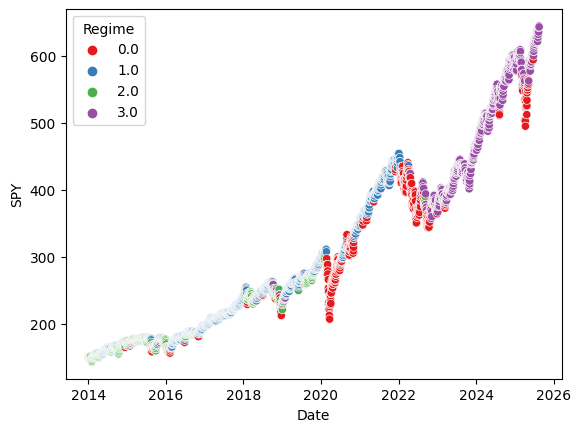

In [256]:
import seaborn as sns
regimestemp = regimes['2014':'2025']
sns.scatterplot(x=regimestemp.index, y='SPY', hue='Regime', data=regimestemp, palette='Set1')